# 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time

In [ ]:
df = pd.read_csv("AMT Anomaly Dataset.csv")

In [ ]:
# Same sampled record from the inference time
np.random.seed(42)

In [ ]:
df.describe()

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,113.600000,105.333333,5.771667,100.466667
std,17.464249,28.049714,12.260819,2.758413,39.521917
min,1.000000,66.000000,85.000000,1.700000,34.000000
25%,15.750000,95.000000,97.000000,4.100000,75.750000
50%,30.500000,105.000000,102.000000,5.050000,87.000000
75%,45.250000,132.750000,111.250000,6.325000,120.000000
max,60.000000,188.000000,138.000000,14.100000,210.000000


In [ ]:
df.head()

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff,severity,action
0,1,72,86,2.1,45,Normal,NO_ACTION
1,2,88,92,3.8,62,Normal,NO_ACTION
2,3,95,98,4.9,79,Normal,NO_ACTION
3,4,66,90,1.7,34,Normal,NO_ACTION
4,5,101,94,5.0,80,Normal,NO_ACTION


In [ ]:
# Group by severity and compute Q3
grouped_severity = df.groupby("severity")[["delay_ms", "clutch_temp_c", "torque_var_pct", "rpm_diff"]].quantile(0.75)
print("Severity Q3 values:")
grouped_severity

Severity Q3 values:


,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff
severity,,,,
Moderate,111.5,107.00,6.075,92.00
Normal,95.5,95.75,4.725,79.25
Severe,159.0,124.25,8.850,167.50


In [ ]:
# Features used
features = ["delay_ms", "clutch_temp_c", "torque_var_pct", "rpm_diff"]

In [ ]:
# Define severity thresholds for each variable
severity_thresholds = {
    "delay_ms": {
        "Moderate": grouped_severity.loc["Normal", "delay_ms"],
        "Severe": grouped_severity.loc["Moderate", "delay_ms"]
    },
    "clutch_temp_c": {
        "Moderate": grouped_severity.loc["Normal", "clutch_temp_c"],
        "Severe": grouped_severity.loc["Moderate", "clutch_temp_c"]
    },
    "torque_var_pct": {
        "Moderate": grouped_severity.loc["Normal", "torque_var_pct"],
        "Severe": grouped_severity.loc["Moderate", "torque_var_pct"]
    },
    "rpm_diff": {
        "Moderate": grouped_severity.loc["Normal", "rpm_diff"],
        "Severe": grouped_severity.loc["Moderate", "rpm_diff"]
    }
}

In [ ]:
print("Thresholds for rule based detection:")
severity_thresholds

Thresholds for rule based detection:


{'delay_ms': {'Moderate': np.float64(95.5), 'Severe': np.float64(111.5)},
 'clutch_temp_c': {'Moderate': np.float64(95.75), 'Severe': np.float64(107.0)},
 'torque_var_pct': {'Moderate': np.float64(4.725),
  'Severe': np.float64(6.074999999999999)},
 'rpm_diff': {'Moderate': np.float64(79.25), 'Severe': np.float64(92.0)}}

In [ ]:
def detect_severity(delay_ms, clutch_temp_c, torque_var_pct, rpm_diff) -> str:
  """
  Detects the severity of the anomaly based on the input features.

  Args:
    delay_ms: The delay in milliseconds.
    clutch_temp_c: The temperature of the clutch in Celsius.
    torque_var_pct: The variance of the torque in percent.
    rpm_diff: The difference in engine RPM.

  Returns:
    The severity of the anomaly.
  """
  rpm_diff = abs(rpm_diff)

  score = 0

  if delay_ms >= severity_thresholds["delay_ms"]["Severe"]:
    score += 2
  elif delay_ms >= severity_thresholds["delay_ms"]["Moderate"]:
    score += 1

  if clutch_temp_c >= severity_thresholds["clutch_temp_c"]["Severe"]:
    score += 2
  elif clutch_temp_c >= severity_thresholds["clutch_temp_c"]["Moderate"]:
    score += 1

  if torque_var_pct >= severity_thresholds["torque_var_pct"]["Severe"]:
    score += 2
  elif torque_var_pct >= severity_thresholds["torque_var_pct"]["Moderate"]:
    score += 1

  if rpm_diff >= severity_thresholds["rpm_diff"]["Severe"]:
    score += 2
  elif rpm_diff >= severity_thresholds["rpm_diff"]["Moderate"]:
    score += 1

  if score >= 6:
    return "Severe"
  elif score >= 3:
    return "Moderate"
  else:
    return "Normal"

In [ ]:
detect_severity(100, 100, 5.5, 90)

'Moderate'

In [ ]:
# Group by action aswell due to right skewness
action_group = df.groupby("action")[["delay_ms","clutch_temp_c","torque_var_pct","rpm_diff"]].quantile(0.75)
print("\nAction Q3 values:")
action_group


Action Q3 values:


,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff
action,,,,
CLUTCH_PRESSURE_RECALIB,149.50,131.50,6.100,107.00
NO_ACTION,95.50,95.75,4.725,79.25
RPM_SYNC,113.75,107.00,6.800,188.75
SHIFT_TIMING_ADJUST,158.75,104.00,5.350,85.00
TORQUE_REDISTRIBUTION,117.00,113.50,9.150,120.00


In [ ]:
# Define thresholds for each action based on main indicative feature
action_thresholds = {
    "SHIFT_TIMING_ADJUST": {
        "delay_ms": action_group.loc["SHIFT_TIMING_ADJUST", "delay_ms"]
    },
    "CLUTCH_PRESSURE_RECALIB": {
        "clutch_temp_c": action_group.loc["CLUTCH_PRESSURE_RECALIB", "clutch_temp_c"]
    },
    "TORQUE_REDISTRIBUTION": {
        "torque_var_pct": action_group.loc["TORQUE_REDISTRIBUTION", "torque_var_pct"]
    },
    "RPM_SYNC": {
        "rpm_diff": action_group.loc["RPM_SYNC", "rpm_diff"]
    }
}

In [ ]:
def normalize(value, min_val, max_val) -> float:
  """
  Normalizes the feature values between 0 and 1 to prevent dominance.

  Args:
    value: The value to normalize.
    min_val: The minimum value of the feature.
    max_val: The maximum value of the feature.

  Returns:
    The normalized value.
  """
  val = (value - min_val) / (max_val - min_val)
  return max(0, min(1, val))

In [ ]:
def predict_action(severity, delay_ms, clutch_temp_c, torque_var_pct, rpm_diff) -> str:
  """
  Predicts the action to take based on the input features.

  Args:
    delay_ms: The delay in milliseconds.
    clutch_temp_c: The temperature of the clutch in Celsius.
    torque_var_pct: The variance of the torque in percent.
    rpm_diff: The difference in RPM.

  Returns:
    The predicted action.
  """
  if severity == "Normal":
    return "NO_ACTION"

  rpm_diff = abs(rpm_diff)

  scores = {
      "SHIFT_TIMING_ADJUST": normalize(delay_ms, 66, 188),
      "CLUTCH_PRESSURE_RECALIB": normalize(clutch_temp_c, 85, 138),
      "TORQUE_REDISTRIBUTION": normalize(torque_var_pct, 1.7, 14.1),
      "RPM_SYNC": normalize(rpm_diff, 34, 210)
  }

  action = max(scores, key=scores.get)

  # Prevent small deviations from triggering an action
  if scores[action] < 0.4:
    return "NO_ACTION"

  return action

In [ ]:
predict_action("Normal", 100, 100, 5.5, 90)

'NO_ACTION'

In [ ]:
severities = []
actions = []

for _, row in df.iterrows():

  severity = detect_severity(
      row["delay_ms"],
      row["clutch_temp_c"],
      row["torque_var_pct"],
      row["rpm_diff"]
  )

  action = predict_action(
      severity,
      row["delay_ms"],
      row["clutch_temp_c"],
      row["torque_var_pct"],
      row["rpm_diff"]
  )

  severities.append(severity)
  actions.append(action)

In [ ]:
df["rule_severity"] = severities
df["rule_action"] = actions

In [ ]:
print("Severity results:")
print(classification_report(df["severity"], df["rule_severity"]))
print("-"*70)
print("Action results:")
print(classification_report(df["action"], df["rule_action"]))

Severity results:
              precision    recall  f1-score   support

    Moderate       0.70      0.88      0.78        26
      Normal       0.91      0.83      0.87        12
      Severe       0.88      0.64      0.74        22

    accuracy                           0.78        60
   macro avg       0.83      0.78      0.80        60
weighted avg       0.80      0.78      0.78        60

----------------------------------------------------------------------
Action results:
                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.55      1.00      0.71         6
              NO_ACTION       0.63      1.00      0.77        12
               RPM_SYNC       0.56      0.83      0.67         6
    SHIFT_TIMING_ADJUST       0.67      0.80      0.73        10
  TORQUE_REDISTRIBUTION       0.89      0.31      0.46        26

               accuracy                           0.65        60
              macro avg       0.66      0.79      0.67   

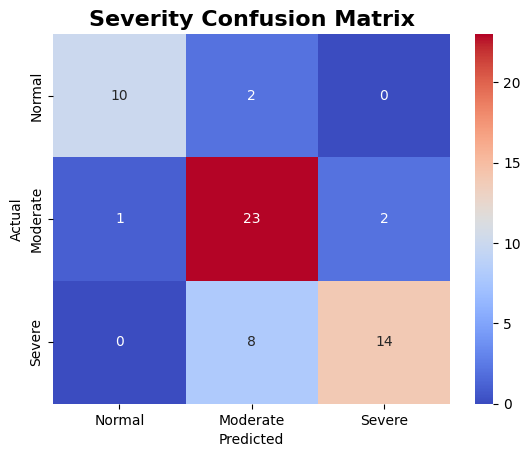

In [ ]:
# Severity confusion matrix
labels = ["Normal", "Moderate", "Severe"]
cm = confusion_matrix(df["severity"], df["rule_severity"], labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Severity Confusion Matrix", fontweight="bold", fontsize=16)
plt.show()

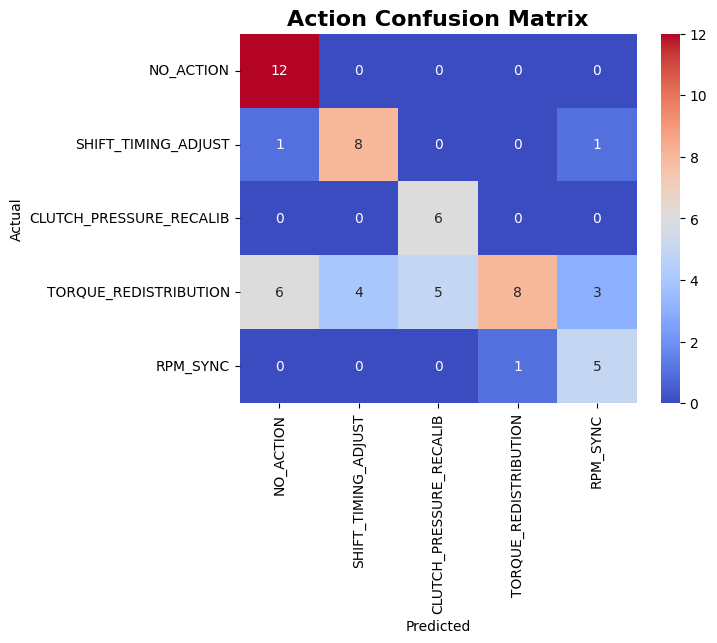

In [ ]:
# Action confusion matrix
labels = ["NO_ACTION", "SHIFT_TIMING_ADJUST", "CLUTCH_PRESSURE_RECALIB", "TORQUE_REDISTRIBUTION", "RPM_SYNC"]
cm = confusion_matrix(df["action"], df["rule_action"], labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Action Confusion Matrix", fontweight='bold', fontsize=16)
plt.show()

In [ ]:
# Severity scores
sev_report = classification_report(
    df["severity"],
    df["rule_severity"],
    output_dict=True
)

severity_f1 = sev_report["weighted avg"]["f1-score"]
severity_acc = sev_report["accuracy"]
print("Severity Accuracy:", severity_acc)
print("Severity Weighted F1:", severity_f1)

Severity Accuracy: 0.7833333333333333
Severity Weighted F1: 0.7819415894193847


In [ ]:
# Action scores
act_report = classification_report(
    df["action"],
    df["rule_action"],
    output_dict=True
)

action_f1 = act_report["weighted avg"]["f1-score"]
action_acc = act_report["accuracy"]
print("Action Accuracy:", action_acc)
print("Action Weighted F1:", action_f1)

Action Accuracy: 0.65
Action Weighted F1: 0.611400970945563


In [ ]:
def get_total_fp_fn(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)

    total_FP = FP.sum()
    total_FN = FN.sum()

    return total_FP, total_FN, cm

In [ ]:
severity_labels = ["Normal", "Moderate", "Severe"]

sev_FP, sev_FN, sev_cm = get_total_fp_fn(
    df["severity"],
    df["rule_severity"],
    severity_labels
)

print("Severity False Positives:", sev_FP)
print("Severity False Negatives:", sev_FN)

Severity False Positives: 13
Severity False Negatives: 13


In [ ]:
action_labels = [
    "NO_ACTION",
    "SHIFT_TIMING_ADJUST",
    "CLUTCH_PRESSURE_RECALIB",
    "TORQUE_REDISTRIBUTION",
    "RPM_SYNC"
]

act_FP, act_FN, act_cm = get_total_fp_fn(
    df["action"],
    df["rule_action"],
    action_labels
)

print("Action False Positives:", act_FP)
print("Action False Negatives:", act_FN)

Action False Positives: 21
Action False Negatives: 21


In [ ]:
def measure_inference_time(df, repeats=1000) -> float:
    """
    Measures the average inference time of the rule-based system.

    Args:
      df (pd.DataFrame): The input dataframe containing the data.
      repeats: The number of times to repeat the inference.

    Returns:
      The average inference time in seconds.
    """
    total_time = 0

    rows = df.to_dict("records")

    for i in range(repeats):
        sample = rows[i % len(rows)]

        start = time.perf_counter()

        # Detect severity
        severity = detect_severity(
            sample["delay_ms"],
            sample["clutch_temp_c"],
            sample["torque_var_pct"],
            sample["rpm_diff"]
        )

        # Predict the action
        predict_action(
            severity,
            sample["delay_ms"],
            sample["clutch_temp_c"],
            sample["torque_var_pct"],
            sample["rpm_diff"]
        )

        end = time.perf_counter()

        total_time += (end - start)

    # Calculate average time
    avg_time = total_time / repeats
    return avg_time

In [ ]:
# Display average inference time
avg_inference_time = measure_inference_time(df)
print("Average inference (rule based):", avg_inference_time, "seconds")

Average inference (rule based): 2.601914000592842e-06 seconds
